# IBD Myeloid Scoring - Data Exploration

In [57]:
print("Hello from my IBD project!")

Hello from my IBD project!


In [58]:
project_name = "IBD Myeloid Scoring"
sample_count = 50
is_pilot = True
print(project_name)
print(sample_count)
print(is_pilot)

IBD Myeloid Scoring
50
True


In [59]:
print(type(project_name))
print(type(sample_count))
print(type(is_pilot))

<class 'str'>
<class 'int'>
<class 'bool'>


In [60]:
significance_threshold = 0.05
print(type(significance_threshold))

<class 'float'>


In [61]:
import pandas as pd

In [97]:
data = {
    "gene": ["TNF", "IL6", "CD14", "FCGR3A", "CCL2"],
    "log2_fold_change": [2.3, 1.8, 3.1, 2.7, 1.5],
    "pvalue": [0.001, 0.23, 0.04, 0.008, 0.041]
}

In [100]:
df = pd.DataFrame(data)
df

,gene,log2_fold_change,pvalue
0,TNF,2.3,0.001
1,IL6,1.8,0.230
2,CD14,3.1,0.040
3,FCGR3A,2.7,0.008
4,CCL2,1.5,0.041


In [79]:
df ["gene"] #subset one column
df[["gene", "pvalue"]] #subset multiple
df.iloc[0:3, 0:2]

,gene,log2_fold_change
0,TNF,2.3
1,IL6,1.8
2,CD14,3.1


In [ ]:
display(df[df["pvalue"] < 0.05])
#display rows with p-val <0.5


,gene,log2_fold_change,pvalue
0,TNF,2.3,0.0010
1,IL6,1.8,0.0230
2,CD14,3.1,0.0004
3,FCGR3A,2.7,0.0080
4,CCL2,1.5,0.0410


In [101]:
df["significant"]= df["pvalue"]<0.05
display(df[df["significant"]]) # this one is safer
display(df[df.significant]) #alternatively, if colname has no space


,gene,log2_fold_change,pvalue,significant
0,TNF,2.3,0.001,True
2,CD14,3.1,0.040,True
3,FCGR3A,2.7,0.008,True
4,CCL2,1.5,0.041,True


,gene,log2_fold_change,pvalue,significant
0,TNF,2.3,0.001,True
2,CD14,3.1,0.040,True
3,FCGR3A,2.7,0.008,True
4,CCL2,1.5,0.041,True


In [78]:
import matplotlib.pyplot as plt

Fontconfig warning: ignoring UTF-8: not a valid region tag
Matplotlib is building the font cache; this may take a moment.


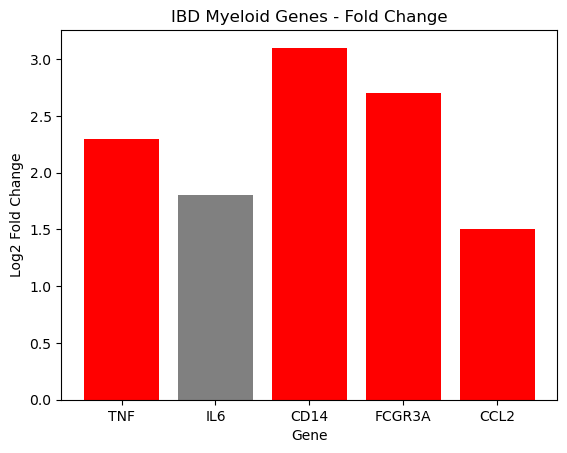

In [104]:
colors = ["red" if sig else "gray" for sig in df["significant"]]
plt.bar(df["gene"], df["log2_fold_change"], color=colors)
plt.xlabel("Gene")
plt.ylabel("Log2 Fold Change")
plt.title("IBD Myeloid Genes - Fold Change")
plt.show() #redundant for Jupyter but important without it


In [103]:
print(df["significant"])


0     True
1    False
2     True
3     True
4     True
Name: significant, dtype: bool


In [121]:
df["label"]= ["high" if fc > 2.2 else "low" for fc in df["log2_fold_change"]]
display(df)


,gene,log2_fold_change,pvalue,significant,abs_fc,label
0,TNF,2.3,0.001,True,2.3,high
1,IL6,1.8,0.230,False,1.8,low
2,CD14,3.1,0.040,True,3.1,high
3,FCGR3A,2.7,0.008,True,2.7,high
4,CCL2,1.5,0.041,True,1.5,low


In [156]:
import numpy as np

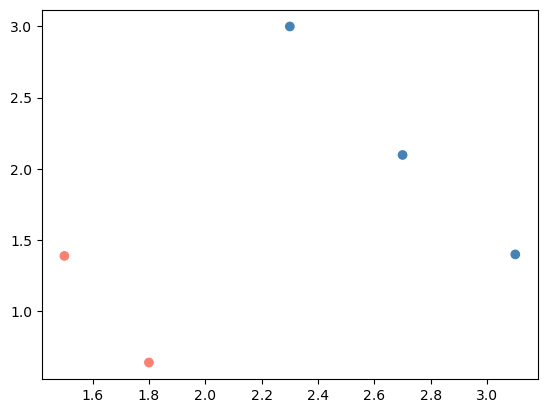

In [164]:
colors= ["steelblue" if lb == "high" else "salmon" for lb in df ["label"]]
plt.scatter(df["log2_fold_change"], -np.log10(df["pvalue"]), color=colors)